# Terrain-Aware Flight Planning

When planning airborne remote sensing over mountainous or hilly terrain, it's important
to account for terrain elevation. This notebook demonstrates how to use HyPlan's terrain
module to:

1. Download and query digital elevation models (DEMs)
2. Compute terrain profiles along flight lines
3. Assess altitude-above-ground-level (AGL) along a flight plan
4. Understand how terrain affects sensor GSD and swath width

**Note:** Terrain functions download DEM tiles from AWS on first use (~30 MB per 1x1 degree tile).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone

from hyplan.flight_line import FlightLine
from hyplan.instruments import AVIRIS3
from hyplan.terrain import generate_demfile, get_elevations, get_min_max_elevations
from hyplan.units import ureg


## 1. Define Flight Lines Over Mountainous Terrain

We'll create a flight line over the San Gabriel Mountains near Los Angeles,
where terrain ranges from ~300 m to over 3000 m.

In [2]:
fl = FlightLine.start_length_azimuth(
    lat1=34.15, lon1=-118.1,
    length=ureg.Quantity(50, "km"),
    az=45.0,  # Northeast across the mountains
    altitude_msl=ureg.Quantity(6000, "meter"),
    site_name="San Gabriel Mountains",
)

print(f"Flight line: {fl.site_name}")
print(f"  Start: ({fl.lat1:.4f}, {fl.lon1:.4f})")
print(f"  End:   ({fl.lat2:.4f}, {fl.lon2:.4f})")
print(f"  Altitude MSL: {fl.altitude_msl}")
print(f"  Heading: {fl.az12:.1f} deg")

Flight line: San Gabriel Mountains
  Start: (34.1500, -118.1000)
  End:   (34.4681, -117.7152)
  Altitude MSL: 6000 meter
  Heading: 45.0 degree deg


## 2. Download DEM and Extract Terrain Profile

Sample terrain elevation along the flight line to understand the AGL variation.

In [3]:
# Sample points along the flight line
coords = np.array(fl.geometry.coords)
lons = coords[:, 0]
lats = coords[:, 1]

# Densify to get more points along the track
n_points = 200
interp_fracs = np.linspace(0, 1, n_points)
interp_lats = np.interp(interp_fracs, np.linspace(0, 1, len(lats)), lats)
interp_lons = np.interp(interp_fracs, np.linspace(0, 1, len(lons)), lons)

# Generate DEM file covering the flight line extent
dem_file = generate_demfile(interp_lats, interp_lons)
print(f"DEM file: {dem_file}")

# Get terrain elevations
terrain_elev_m = get_elevations(interp_lats, interp_lons, dem_file)
print(f"Terrain elevation range: {terrain_elev_m.min():.0f} - {terrain_elev_m.max():.0f} m")

DEM file: /var/folders/tk/dltx8gp544z3_ddzcb8c1_7r0000gn/T/hyplan/dem_cache/34.05_-118.20_34.57_-117.62.tif
Terrain elevation range: 234 - 2072 m


/Users/rpavlick/.pyenv/versions/3.11.11/lib/python3.11/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


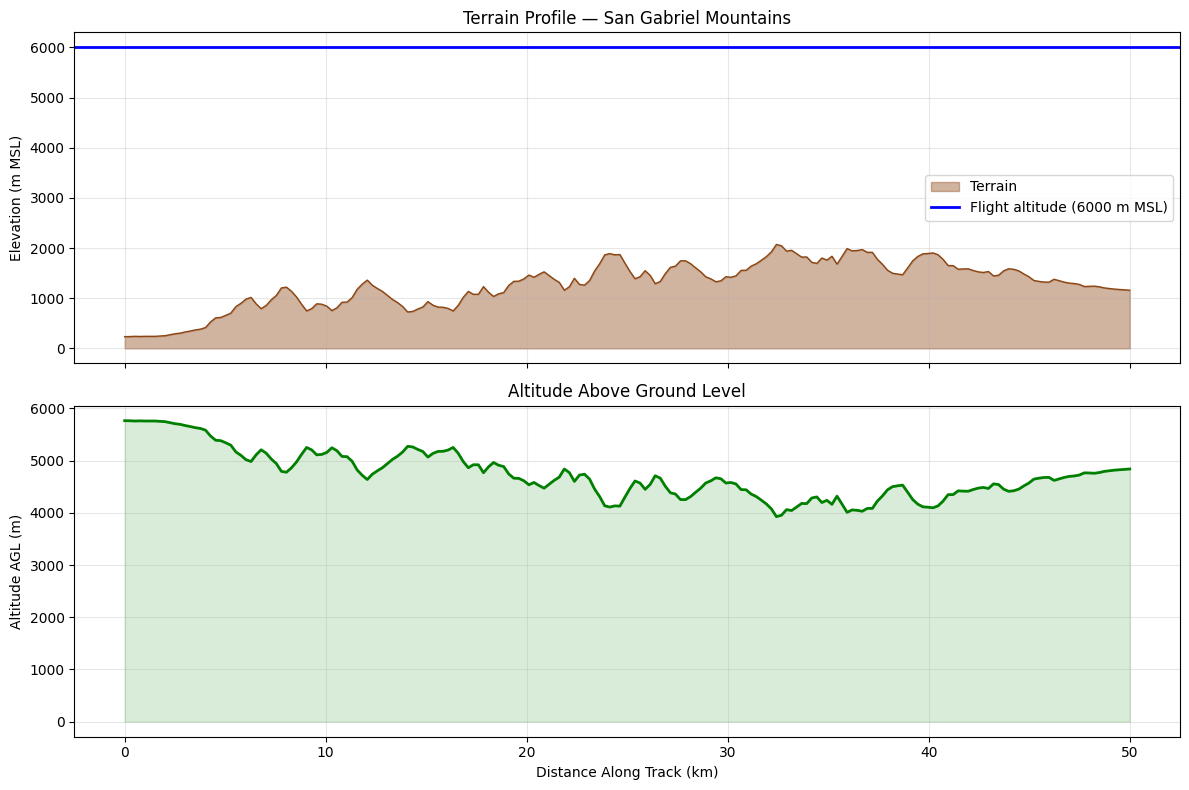

AGL range: 3928 - 5766 m


In [4]:
# Compute distances along track (approximate)
from pymap3d import vincenty

distances_km = [0]
for i in range(1, len(interp_lats)):
    d, _ = vincenty.vdist(interp_lats[i-1], interp_lons[i-1], interp_lats[i], interp_lons[i])
    distances_km.append(distances_km[-1] + d / 1000)
distances_km = np.array(distances_km)

# Plot terrain profile with flight altitude
flight_alt_m = fl.altitude_msl.to(ureg.meter).magnitude
agl_m = flight_alt_m - terrain_elev_m

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: altitude profile
ax1.fill_between(distances_km, 0, terrain_elev_m, color="saddlebrown", alpha=0.4, label="Terrain")
ax1.plot(distances_km, terrain_elev_m, color="saddlebrown", linewidth=1)
ax1.axhline(y=flight_alt_m, color="blue", linewidth=2, label=f"Flight altitude ({flight_alt_m:.0f} m MSL)")
ax1.set_ylabel("Elevation (m MSL)")
ax1.set_title(f"Terrain Profile — {fl.site_name}")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom: AGL
ax2.plot(distances_km, agl_m, color="green", linewidth=2)
ax2.fill_between(distances_km, 0, agl_m, color="green", alpha=0.15)
ax2.set_xlabel("Distance Along Track (km)")
ax2.set_ylabel("Altitude AGL (m)")
ax2.set_title("Altitude Above Ground Level")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AGL range: {agl_m.min():.0f} - {agl_m.max():.0f} m")

## 3. Terrain Impact on Sensor Performance

Because GSD and swath width depend on altitude AGL, terrain variation causes these
to change along the flight line. High terrain means lower AGL, finer GSD, but
narrower swath.

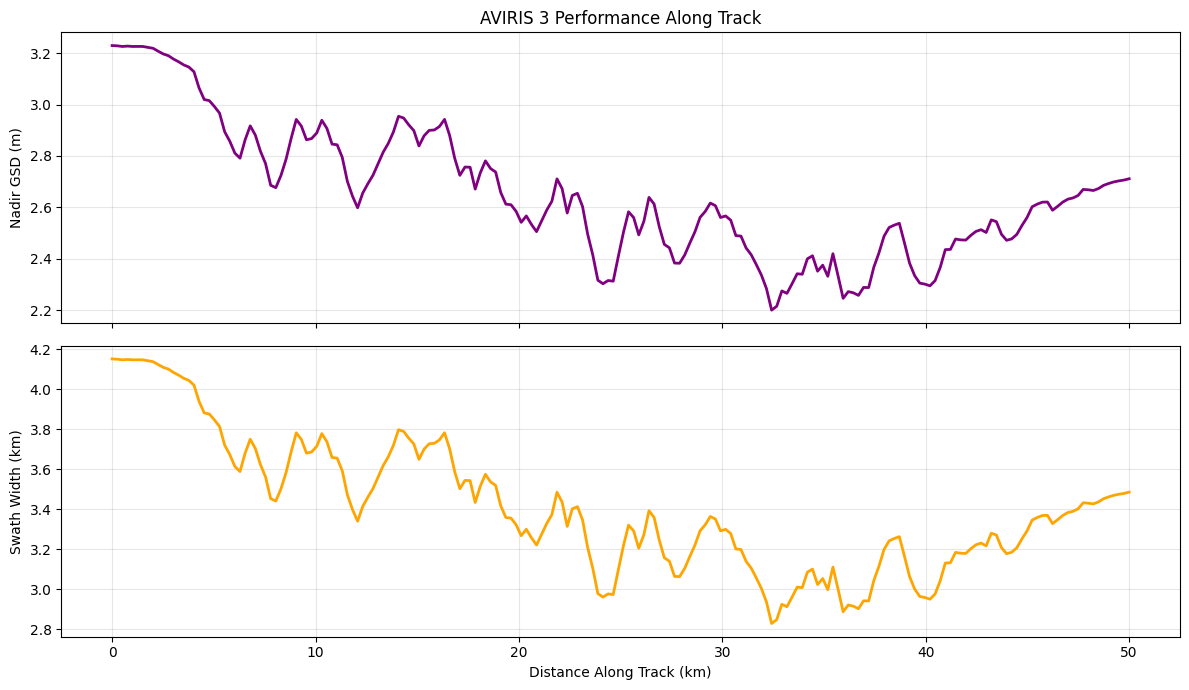

GSD range: 2.2 - 3.2 m
Swath width range: 2.83 - 4.15 km


In [5]:
sensor = AVIRIS3()

# Compute GSD and swath width at each point along the track
gsd_m = np.array([
    sensor.ground_sample_distance(ureg.Quantity(agl, "meter")).to(ureg.meter).magnitude
    for agl in agl_m
])

swath_m = np.array([
    sensor.swath_width(ureg.Quantity(agl, "meter")).to(ureg.meter).magnitude
    for agl in agl_m
])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(distances_km, gsd_m, color="purple", linewidth=2)
ax1.set_ylabel("Nadir GSD (m)")
ax1.set_title(f"{sensor.name} Performance Along Track")
ax1.grid(True, alpha=0.3)

ax2.plot(distances_km, swath_m / 1000, color="orange", linewidth=2)
ax2.set_xlabel("Distance Along Track (km)")
ax2.set_ylabel("Swath Width (km)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"GSD range: {gsd_m.min():.1f} - {gsd_m.max():.1f} m")
print(f"Swath width range: {swath_m.min()/1000:.2f} - {swath_m.max()/1000:.2f} km")

## 4. Choosing a Flight Altitude

Compare different flight altitudes to find one that maintains a target GSD
even over the highest terrain.

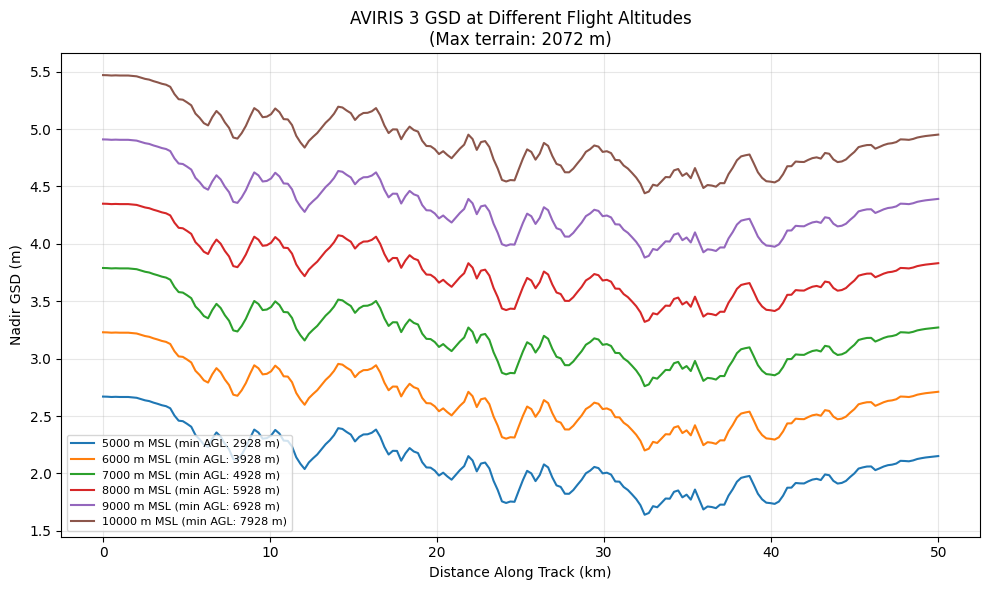

In [6]:
altitudes_msl = [5000, 6000, 7000, 8000, 9000, 10000]
max_terrain = terrain_elev_m.max()

fig, ax = plt.subplots(figsize=(10, 6))

for alt in altitudes_msl:
    agl_profile = alt - terrain_elev_m
    # Skip if altitude is below terrain
    if np.any(agl_profile <= 0):
        continue
    gsd_profile = np.array([
        sensor.ground_sample_distance(ureg.Quantity(a, "meter")).to(ureg.meter).magnitude
        for a in agl_profile
    ])
    ax.plot(distances_km, gsd_profile, label=f"{alt} m MSL (min AGL: {agl_profile.min():.0f} m)")

ax.set_xlabel("Distance Along Track (km)")
ax.set_ylabel("Nadir GSD (m)")
ax.set_title(f"{sensor.name} GSD at Different Flight Altitudes\n(Max terrain: {max_terrain:.0f} m)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Terrain-Aware Flight Box Generation

The previous sections showed how terrain affects sensor performance for a *single*
flight line. When planning a *box* of parallel lines, terrain creates a harder problem:
the swath width varies across the box, so uniform line spacing can leave gaps over
ridges or waste overlap in valleys.

`box_around_center_terrain` solves this by:

1. Downloading a DEM covering the survey box
2. Using ray-terrain intersection (`swath.generate_swath_polygon`) to measure the
   actual swath width at each line position
3. Placing lines with variable spacing so the *minimum* swath width at each position
   guarantees the requested overlap

Flight altitude MSL is provided directly by the caller. For `LineScanner` sensors,
`altitude_msl_for_pixel_size` computes the altitude needed to achieve a target GSD
at the lowest terrain point in the box.

We compare this with the flat-earth `box_around_center_line` to see the difference.

In [7]:
from hyplan.flight_box import box_around_center_terrain, box_around_center_line, altitude_msl_for_pixel_size
from hyplan.swath import generate_swath_polygon, calculate_swath_widths
from hyplan.terrain import generate_demfile, get_min_max_elevations
import geopandas as gpd

sensor = AVIRIS3()
pixel_size = ureg.Quantity(3, "meter")

# San Gabriel Mountains — significant terrain relief
lat0, lon0 = 34.25, -117.9
azimuth = 90.0  # East-west lines across the mountain range
box_length = ureg.Quantity(30, "km")
box_width = ureg.Quantity(15, "km")

# Compute altitude MSL that achieves the target pixel size at lowest terrain
dem_file = generate_demfile(
    *zip(*[(lat0, lon0)]),  # seed the DEM around the box center
)
altitude_msl = altitude_msl_for_pixel_size(sensor, pixel_size, dem_file)
print(f"Altitude for {pixel_size} pixel size: {altitude_msl:.0f}")

# Generate terrain-aware flight lines
terrain_lines = box_around_center_terrain(
    instrument=sensor,
    altitude_msl=altitude_msl,
    lat0=lat0, lon0=lon0,
    azimuth=azimuth,
    box_length=box_length,
    box_width=box_width,
    box_name="Terrain",
    overlap=20.0,
    safe_altitude=ureg.Quantity(300, "meter"),
)

print(f"Terrain-aware: {len(terrain_lines)} lines")
print(f"  Altitude MSL: {terrain_lines[0].altitude_msl}")
for fl in terrain_lines:
    print(f"  {fl.site_name}: length={fl.length.to(ureg.km):.1f}")

Altitude for 3 meter pixel size: 5355 meter
Terrain-aware: 8 lines
  Altitude MSL: 5354.873603978295 meter
  Terrain_L01_FL176: length=30.1 kilometer
  Terrain_L02_FL176: length=30.1 kilometer
  Terrain_L03_FL176: length=30.1 kilometer
  Terrain_L04_FL176: length=30.1 kilometer
  Terrain_L05_FL176: length=30.1 kilometer
  Terrain_L06_FL176: length=30.1 kilometer
  Terrain_L07_FL176: length=30.1 kilometer
  Terrain_L08_FL176: length=30.2 kilometer


### Compare with flat-earth line spacing

`box_around_center_line` uses a constant swath width (no terrain). Over mountainous
terrain, this can leave gaps where ridges narrow the swath.

In [8]:
# Generate flat-earth lines at the same altitude for comparison
flat_lines = box_around_center_line(
    instrument=sensor,
    altitude_msl=terrain_lines[0].altitude_msl,
    lat0=lat0, lon0=lon0,
    azimuth=azimuth,
    box_length=box_length,
    box_width=box_width,
    box_name="Flat",
    overlap=20.0,
)

print(f"Flat-earth: {len(flat_lines)} lines")
print(f"Terrain-aware: {len(terrain_lines)} lines")
print(f"\nTerrain-aware planning added {len(terrain_lines) - len(flat_lines)} extra line(s) to maintain coverage.")

Flat-earth: 5 lines
Terrain-aware: 8 lines

Terrain-aware planning added 3 extra line(s) to maintain coverage.


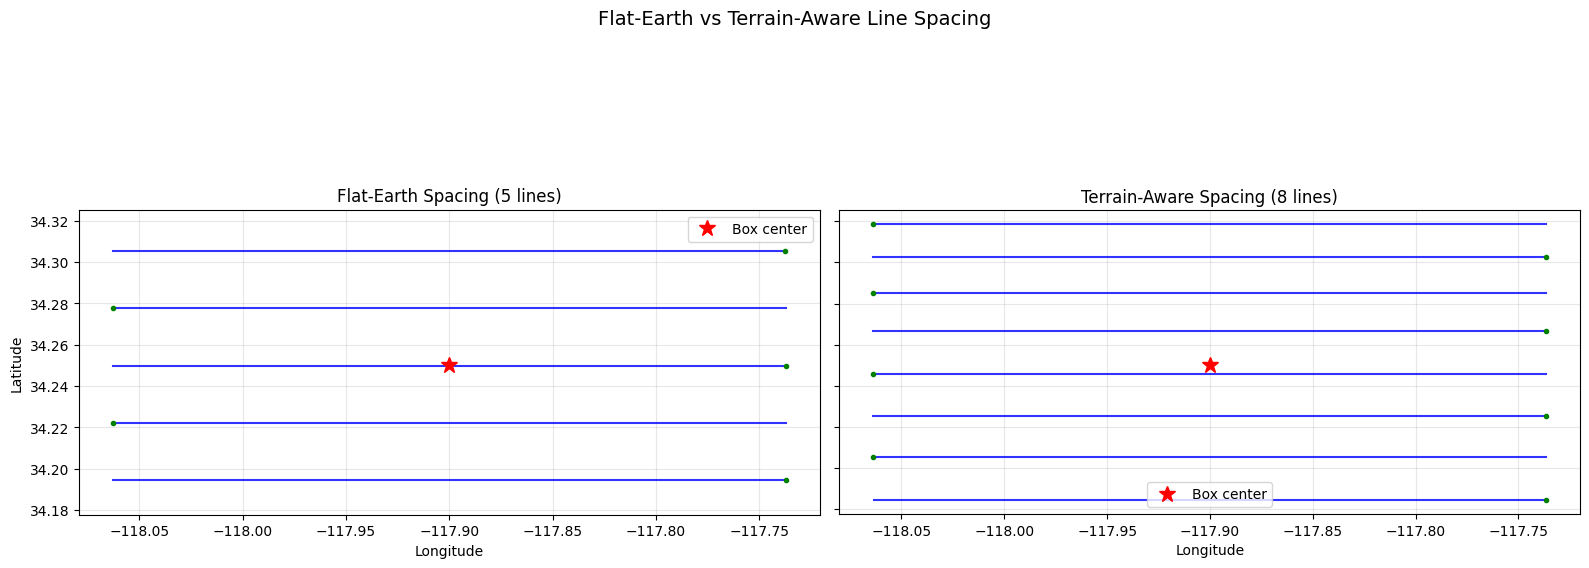

In [9]:
# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, lines_list, title in [
    (ax1, flat_lines, f"Flat-Earth Spacing ({len(flat_lines)} lines)"),
    (ax2, terrain_lines, f"Terrain-Aware Spacing ({len(terrain_lines)} lines)"),
]:
    for fl in lines_list:
        x, y = fl.geometry.xy
        ax.plot(x, y, "b-", linewidth=1.5, alpha=0.8)
        ax.plot(x[0], y[0], "go", markersize=3)

    ax.plot(lon0, lat0, "r*", markersize=12, label="Box center")
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.legend()

ax1.set_ylabel("Latitude")
plt.suptitle("Flat-Earth vs Terrain-Aware Line Spacing", fontsize=14)
plt.tight_layout()
plt.show()

### Swath width analysis

Compare the actual terrain-aware swath widths for both sets of lines.
The terrain-aware planner spaces lines more tightly where terrain narrows the swath.

In [10]:
# Compute swath widths for both sets of lines
def swath_stats(lines_list, sensor):
    """Compute swath width statistics for a list of flight lines."""
    stats = []
    for fl in lines_list:
        swath_poly = generate_swath_polygon(fl, sensor)
        widths = calculate_swath_widths(swath_poly)
        stats.append(widths)
    return stats

terrain_stats = swath_stats(terrain_lines, sensor)
flat_stats = swath_stats(flat_lines, sensor)

# Print comparison table
print(f"{'Line':<25s} {'Min (m)':>8s} {'Mean (m)':>9s} {'Max (m)':>8s}")
print("=" * 53)
print("TERRAIN-AWARE:")
for fl, s in zip(terrain_lines, terrain_stats):
    print(f"  {fl.site_name:<23s} {s['min_width']:>8.0f} {s['mean_width']:>9.0f} {s['max_width']:>8.0f}")

print("\nFLAT-EARTH:")
for fl, s in zip(flat_lines, flat_stats):
    print(f"  {fl.site_name:<23s} {s['min_width']:>8.0f} {s['mean_width']:>9.0f} {s['max_width']:>8.0f}")

# Theoretical swath at sea level
theoretical = sensor.swath_width(terrain_lines[0].altitude_msl).to(ureg.meter).magnitude
print(f"\nTheoretical swath (flat, sea level): {theoretical:.0f} m")

Line                       Min (m)  Mean (m)  Max (m)
TERRAIN-AWARE:
  Terrain_L01_FL176           2237      2666     3026
  Terrain_L02_FL176           2403      2791     3117
  Terrain_L03_FL176           2579      2908     3236
  Terrain_L04_FL176           2874      3111     3375
  Terrain_L05_FL176           2809      3185     3456
  Terrain_L06_FL176           2789      3252     3544
  Terrain_L07_FL176           2921      3219     3531
  Terrain_L08_FL176           3189      3362     3578

FLAT-EARTH:
  Flat_L01_FL176              2413      2762     3104
  Flat_L02_FL176              2735      2997     3314
  Flat_L03_FL176              2833      3188     3449
  Flat_L04_FL176              2809      3230     3541
  Flat_L05_FL176              3090      3298     3534

Theoretical swath (flat, sea level): 3856 m


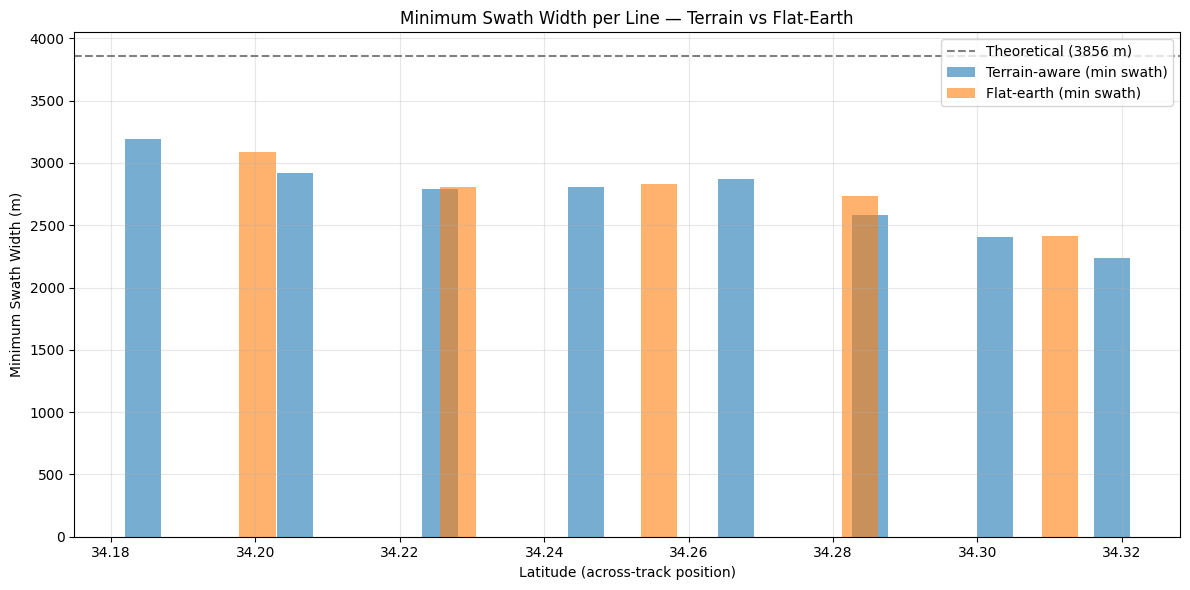

In [11]:
# Visualize line spacing vs swath width
fig, ax = plt.subplots(figsize=(12, 6))

# Get across-track positions (latitude for E-W lines)
terrain_lats = sorted([fl.lat1 for fl in terrain_lines])
flat_lats = sorted([fl.lat1 for fl in flat_lines])

terrain_min_widths = [s["min_width"] for s in terrain_stats]
flat_min_widths = [s["min_width"] for s in flat_stats]

# Sort by latitude for plotting
terrain_order = np.argsort([fl.lat1 for fl in terrain_lines])
flat_order = np.argsort([fl.lat1 for fl in flat_lines])

ax.bar(
    [terrain_lats[i] for i in range(len(terrain_lats))],
    [terrain_min_widths[terrain_order[i]] for i in range(len(terrain_order))],
    width=0.005, alpha=0.6, label="Terrain-aware (min swath)", color="tab:blue",
)
ax.bar(
    [flat_lats[i] + 0.006 for i in range(len(flat_lats))],
    [flat_min_widths[flat_order[i]] for i in range(len(flat_order))],
    width=0.005, alpha=0.6, label="Flat-earth (min swath)", color="tab:orange",
)

ax.axhline(y=theoretical, color="gray", linestyle="--", label=f"Theoretical ({theoretical:.0f} m)")
ax.set_xlabel("Latitude (across-track position)")
ax.set_ylabel("Minimum Swath Width (m)")
ax.set_title("Minimum Swath Width per Line — Terrain vs Flat-Earth")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Swath polygons on a map

Visualize the actual swath footprints to see how terrain-aware spacing
eliminates coverage gaps.

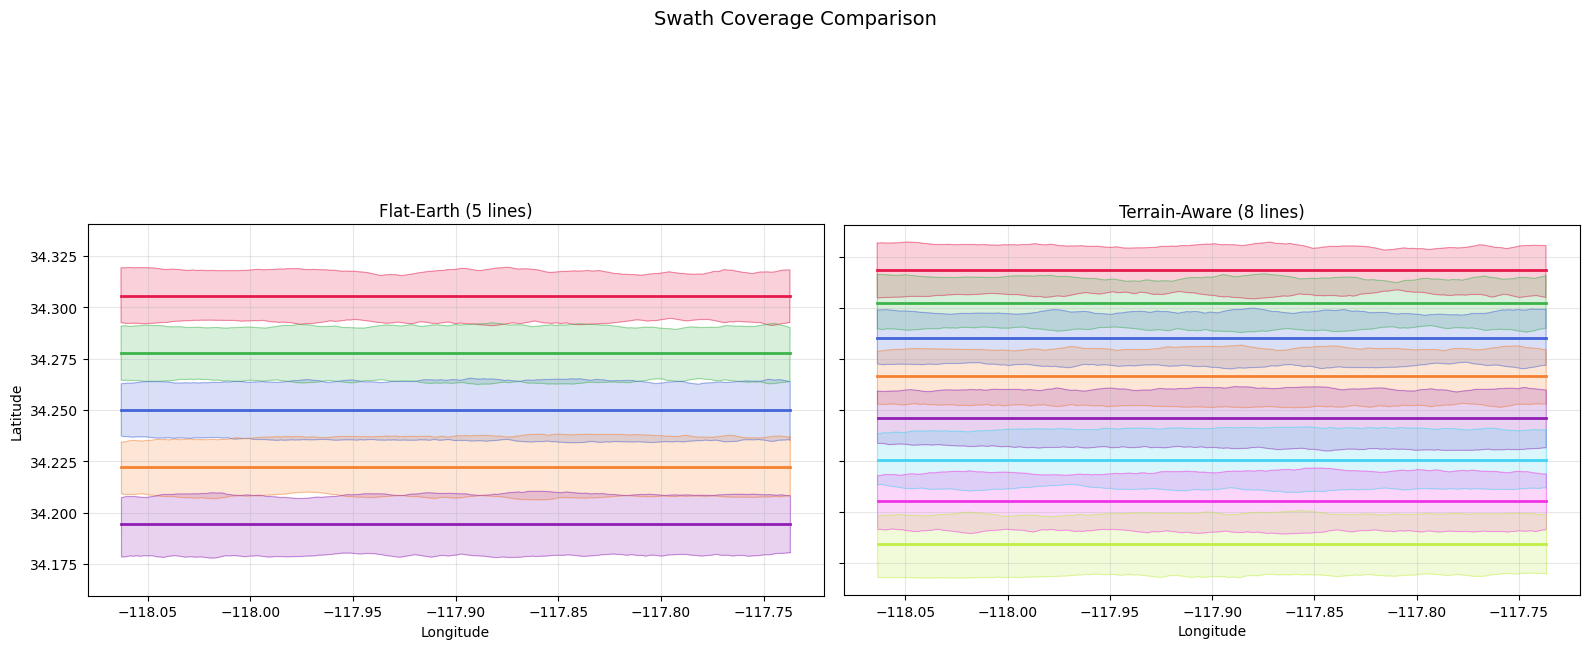

In [12]:
colors = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
          "#42d4f4", "#f032e6", "#bfef45", "#fabed4", "#469990"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

for ax, lines_list, title in [
    (ax1, flat_lines, f"Flat-Earth ({len(flat_lines)} lines)"),
    (ax2, terrain_lines, f"Terrain-Aware ({len(terrain_lines)} lines)"),
]:
    for i, fl in enumerate(lines_list):
        color = colors[i % len(colors)]
        # Draw swath polygon
        swath_poly = generate_swath_polygon(fl, sensor)
        xs, ys = swath_poly.exterior.xy
        ax.fill(xs, ys, alpha=0.2, color=color)
        ax.plot(xs, ys, color=color, linewidth=0.5, alpha=0.5)
        # Draw flight line
        x, y = fl.geometry.xy
        ax.plot(x, y, color=color, linewidth=2)

    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

ax1.set_ylabel("Latitude")
plt.suptitle("Swath Coverage Comparison", fontsize=14)
plt.tight_layout()
plt.show()

### Interactive map with Folium

In [13]:
import folium

m = folium.Map(location=[lat0, lon0], zoom_start=11, tiles="OpenTopoMap")

for i, fl in enumerate(terrain_lines):
    color = colors[i % len(colors)]
    # Swath polygon
    swath_poly = generate_swath_polygon(fl, sensor)
    folium.GeoJson(
        swath_poly.__geo_interface__,
        style_function=lambda x, c=color: {
            "fillColor": c, "color": c, "weight": 1, "fillOpacity": 0.15
        },
    ).add_to(m)
    # Flight line
    coords = [(lat, lon) for lon, lat in fl.geometry.coords]
    widths = calculate_swath_widths(swath_poly)
    tooltip = f"{fl.site_name} | min swath: {widths['min_width']:.0f} m"
    folium.PolyLine(coords, color=color, weight=3, tooltip=tooltip).add_to(m)

m

## 6. Optimal Flight Azimuth from Terrain Aspect

For Mode 3 planning over mountainous terrain, Zhao et al. (2021) recommend
orienting flight lines **perpendicular to the dominant terrain gradient** to
minimise altitude variation within each strip. `terrain_aspect_azimuth()`
returns the dominant downslope direction; adding 90° gives the flight azimuth
that keeps terrain elevation most constant along each line.

In [14]:
from hyplan.terrain import terrain_aspect_azimuth
from shapely.geometry import box as shapely_box
import pymap3d.vincenty

# Build a bounding polygon for the San Gabriel survey area
half_len_deg = (box_length.to("meter").magnitude / 2) / 111_320
half_wid_deg = (box_width.to("meter").magnitude / 2) / 111_320
survey_polygon = shapely_box(
    lon0 - half_len_deg, lat0 - half_wid_deg,
    lon0 + half_len_deg, lat0 + half_wid_deg,
)

downslope_az = terrain_aspect_azimuth(survey_polygon)
optimal_flight_az = (downslope_az + 90) % 360

print(f"Dominant downslope azimuth : {downslope_az:.1f}°")
print(f"Recommended flight azimuth : {optimal_flight_az:.1f}° "
      f"(perpendicular to slope)")
print(f"Current flight azimuth     : {azimuth:.1f}°")

Dominant downslope azimuth : 184.6°
Recommended flight azimuth : 274.6° (perpendicular to slope)
Current flight azimuth     : 90.0°


## 7. Mode 3 — Variable Altitude per Flight Line

**Mode 2** (used above) flies all lines at a single fixed MSL altitude.  
**Mode 3** assigns each line its own altitude based on the mean terrain
elevation along its nadir track plus a constant AGL offset. This keeps
GSD and swath width stable across mountainous terrain.

Pass  to  to activate Mode 3.

In [15]:
# Desired AGL -- matches the sensor's requirement for 3 m pixel size
target_agl = sensor.altitude_agl_for_ground_sample_distance(pixel_size)
print(f"Target AGL for {pixel_size} pixels: {target_agl:.0f}")

# Mode 3: each line gets its own altitude from mean nadir terrain + target_agl
mode3_lines = box_around_center_terrain(
    instrument=sensor,
    altitude_msl=altitude_msl,       # reference for box geometry
    lat0=lat0, lon0=lon0,
    azimuth=azimuth,
    box_length=box_length,
    box_width=box_width,
    box_name="Mode3",
    overlap=20.0,
    safe_altitude=ureg.Quantity(300, "meter"),
    target_agl=target_agl,
)

print(f"Mode 2: {len(terrain_lines)} lines at fixed altitude "
      f"{terrain_lines[0].altitude_msl:.0f}")
print(f"Mode 3: {len(mode3_lines)} lines with variable altitude")
for fl in mode3_lines:
    print(f"  {fl.site_name}: altitude_msl = {fl.altitude_msl:.0f}")

Target AGL for 3 meter pixels: 5356 meter
Mode 2: 8 lines at fixed altitude 5355 meter
Mode 3: 6 lines with variable altitude
  Mode3_L01_FL230: altitude_msl = 7010 meter
  Mode3_L02_FL223: altitude_msl = 6784 meter
  Mode3_L03_FL213: altitude_msl = 6485 meter
  Mode3_L04_FL200: altitude_msl = 6087 meter
  Mode3_L05_FL209: altitude_msl = 6377 meter
  Mode3_L06_FL201: altitude_msl = 6127 meter


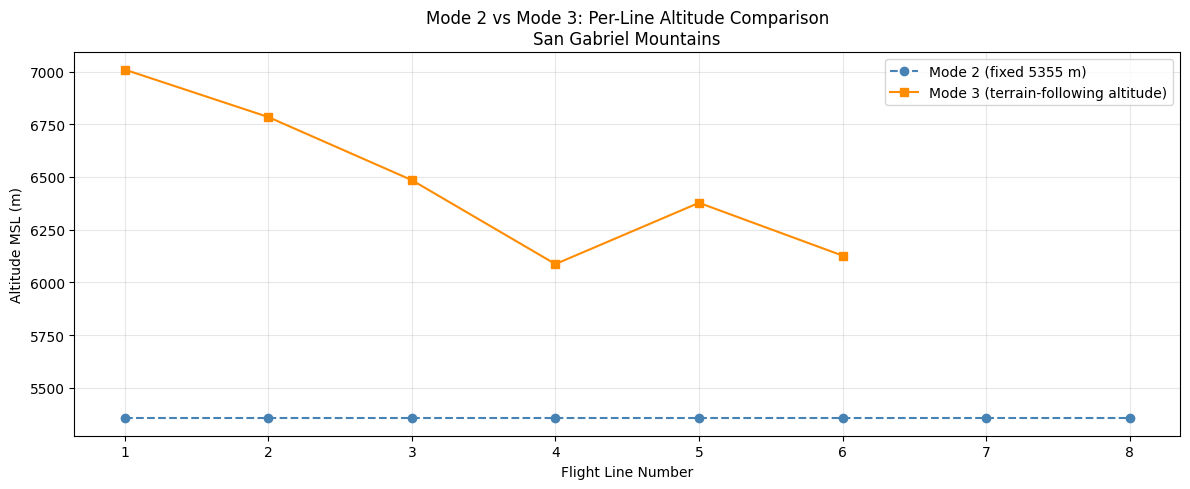

Mode 2 altitude range: 5355-5355 m (constant)
Mode 3 altitude range: 6087-7010 m (923 m variation)


In [16]:
# Compare per-line altitudes: Mode 2 (constant) vs Mode 3 (variable)
fig, ax = plt.subplots(figsize=(12, 5))

line_nums_2 = range(1, len(terrain_lines) + 1)
alts_2 = [fl.altitude_msl.to("meter").magnitude for fl in terrain_lines]

line_nums_3 = range(1, len(mode3_lines) + 1)
alts_3 = [fl.altitude_msl.to("meter").magnitude for fl in mode3_lines]

ax.plot(line_nums_2, alts_2, "o--", color="steelblue",
        label=f"Mode 2 (fixed {alts_2[0]:.0f} m)", linewidth=1.5)
ax.plot(line_nums_3, alts_3, "s-",  color="darkorange",
        label="Mode 3 (terrain-following altitude)", linewidth=1.5)

ax.set_xlabel("Flight Line Number")
ax.set_ylabel("Altitude MSL (m)")
ax.set_title("Mode 2 vs Mode 3: Per-Line Altitude Comparison\n"
             "San Gabriel Mountains")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mode 2 altitude range: {min(alts_2):.0f}-{max(alts_2):.0f} m (constant)")
print(f"Mode 3 altitude range: {min(alts_3):.0f}-{max(alts_3):.0f} m "
      f"({max(alts_3)-min(alts_3):.0f} m variation)")

### Summary: Flight Line Planning Modes

| Mode | Function | Altitude | Spacing | Best for |
|------|----------|----------|---------|----------|
| 1 | `box_around_center_line` | Fixed | Fixed (flat-earth) | Flat terrain |
| 2 | `box_around_center_terrain` | Fixed | Variable (DEM) | Moderate relief |
| 3 | `box_around_center_terrain(target_agl=...)` | Per-line (terrain + AGL) | Variable (DEM) | Mountainous terrain |

*Reference: Zhao et al. (2021), IEEE J. Sel. Topics Appl. Earth Obs. Remote Sens., 14, 6206–6217.*